# Validation of NEDAS using the Lorenz 1996 model case

The Lorenz 1996 model is a one-dimensional model with $N_x = 40$ variables defined on a cyclic domain. It represents a mid-latitude zonal circle of global atmosphere with governing equations:

$$ \frac{\mathrm{d} x_n}{\mathrm{d} t} = (x_{n+1} - x_{n-2})x_{n-1} - x_n + F, $$

for $n = 1, \ldots, N_x$. The forcing $F = 8$ displays chaotic behavior. While the model is non-dimensional, it is analogous to atmospheric systems with time units $\Delta t = 0.05$ representing a $\sim 6$ hour period.

Thanks to its simplicity, the Lorenz-96 model is often used in DA for prototyping and benchmarking new methods. In this notebook, we will use this model to reproduce results in section 5.5 of [Boquet's lecture notes](https://cerea.enpc.fr/HomePages/bocquet/teaching/assim-mb-en-0.52.pdf), which serves as a validation of implementation correctness for the deterministic EnKF algorithms in NEDAS.

## System setup (optional, for Google Colab only)

In [1]:
to_install = False

if to_install:
    # 1. Install the latest version of NEDAS on develop branch
    %cd ~
    %rm -rf NEDAS
    !git clone https://github.com/nansencenter/NEDAS.git
    %cd NEDAS
    %pip install .
    
    # 2. Install additional dependencies
    # numba provides JIT compilation of python function to speed it up during runtime
    %pip install numba
    # cmocean provides better colormaps for visualization
    %pip install cmocean
    # ipython widgets for interactive plots
    %pip install ipywidgets
    
    # 3. Clone the tutorial repo too
    %mkdir ~/work
    %cd ~/work
    %rm -rf NEDAS_tutorials
    !git clone https://github.com/myying/NEDAS_tutorials.git
    %cd ~/work/NEDAS_tutorials


## Load the NEDAS system and dependencies

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

from NEDAS.config import Config
from NEDAS import get_scheme

## Initialization

The config object holds all parameters defined in a yaml file, we can also make some changes

In [3]:
config = Config(config_file="lorenz96/config.yml", quiet=True)

In [4]:
# ensemble size
config.nens = 20

In [5]:
# set experiment duration
from datetime import datetime, timedelta
ncycle = 2000   # number of cycles
config.time_end = config.time_start + ncycle * timedelta(hours=config.cycle_period)
config.time_analysis_end = config.time_end

In [7]:
obs_rec_id = 0

In [7]:
# observation error standard deviation
config.obs_def[obs_rec_id]['err']['std'] = 1

In [9]:
# localization radius (number of grid points), set to np.inf if no localization should be applied
config.obs_def[obs_rec_id]['hroi'] = 5

In [10]:
# try changing the observation network here
# obs_x defines the obs locations
obs_x = [i for i in range(0, 20, 1)]  # only observe left half of domain

config.dataset_def['synthetic']['obs_x'] = obs_x
config.obs_def[obs_rec_id]['nobs'] = len(obs_x)

## Run the main scheme

The main scheme is the top level manager of runtime execution, it can be initialized with the config object.

Notes: 

- The first cycle takes a bit longer since the python functions are being compiled by numba.njit
- NEDAS always use real datetime to handle time controls. Lorenz96 is nondimensional, so we used the convention of $\Delta t = 0.05$ corresponding to 6 hours.

In [7]:
scheme = get_scheme(config)

In [11]:
%rm -rf lorenz96/work/*

In [9]:
scheme()

## Collect data from memory

In [8]:
def get_truth(scheme):
    model = scheme.c.models['lorenz96']
    scheme.c.time = scheme.c.config.time_start
    
    truth_state = []
    while scheme.c.time < scheme.c.config.time_end:
        truth_state.append(model.read_var_from_memory(tag='truth', name='state', member=None, time=scheme.c.time))
        scheme.c.time = scheme.c.next_time

    return np.array(truth_state)

def get_model_state(scheme, tag):
    model = scheme.c.models['lorenz96']
    scheme.c.time = scheme.c.config.time_start

    ens_state = []
    while scheme.c.time < scheme.c.config.time_end:
        ens = []
        for m in range(scheme.c.nens):
            try:
                state = model.read_var_from_memory(tag=tag, name='state', member=m, time=scheme.c.time)
            except Exception:
                state = model.read_var_from_memory(tag='current', name='state', member=m, time=scheme.c.time)
            ens.append(state)
        ens_state.append(ens)
        scheme.c.time = scheme.c.next_time
    return np.array(ens_state)

def get_obs(scheme):
    dataset = scheme.c.datasets['synthetic']
    nobs = scheme.c.obs.info.records[0].nobs
    scheme.c.time = scheme.c.config.time_start
    obs_val = []
    obs_x = []
    while scheme.c.time < scheme.c.config.time_end:
        if scheme.c.time >= scheme.c.config.time_analysis_start and scheme.c.time <= scheme.c.config.time_analysis_end:
            seq = dataset.read_obs_from_memory(tag='raw', name='state', member=None, time=scheme.c.time)
            obs_val.append(seq['obs'])
            obs_x.append(seq['x'])
        else:
            obs_val.append(np.full(nobs, np.nan))
            obs_x.append(np.full(nobs, np.nan))
        scheme.c.time = scheme.c.next_time
    return np.array(obs_val), np.array(obs_x)

In [11]:
truth_state = get_truth(scheme)
post_state = get_model_state(scheme, 'post')

obs_val, obs_x = get_obs(scheme)

mse_ts = np.mean((np.mean(post_state, axis=1) - truth_state)**2, axis=1)

## Some diagnostics

### Animation of the state over time (first 100 cycles)

In [26]:
%mkdir -p lorenz96/work/plots

grid = scheme.c.grid
dt = 0.05

nt = min(100, len(truth_state))  # no more than 100 cycles shown in animation
for n in range(0, nt, 4):        # show every 4 frames (dt = 0.2)
    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    # plot ensemble members in cyan
    for m in range(scheme.c.nens):
        ax.plot(grid.x, post_state[n,m,:], color='c', alpha=0.5)

    # plot ensemble mean in thick blue
    ax.plot(grid.x, np.mean(post_state[n,...], axis=0), color='b', linewidth=2, label='Posterior mean')

    # plot observations
    ax.plot(obs_x[n,:], obs_val[n,:], 'rx', markersize=8, label='Obs')

    # plot the truth
    ax.plot(grid.x, truth_state[n,:], color='k', linewidth=2, label='Truth')

    ax.set_title(f"t = {n*dt:7.2f}")
    ax.set_xlim(-1, grid.nx+1)
    ax.set_ylim(-10, 15)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    plt.savefig(f"lorenz96/work/plots/state_{n:3}.png")
    plt.close()

# make an animation
from PIL import Image
frames = []
for n in range(0, nt, 4):
    path = f"lorenz96/work/plots/state_{n:3}.png"
    frames.append(Image.open(path))

# Save as GIF
frames[-1].save(f'lorenz96/state_animation.gif',
               save_all=True,
               append_images=frames[0:],
               optimize=False,
               duration=300, # ms per frame
               loop=0)

display(HTML(f'<img src=\"lorenz96/state_animation.gif\">'))

### Error time series

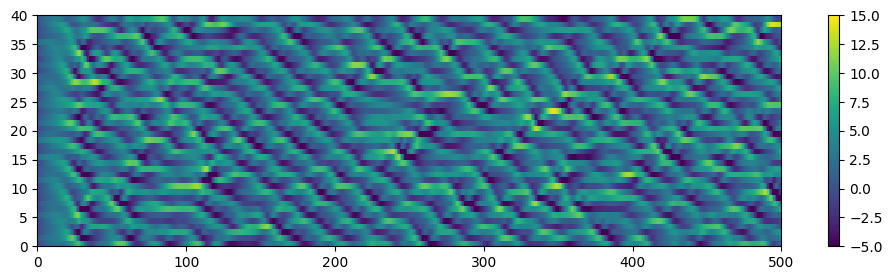

In [14]:
# Hovmoeller diagram of the truth (time: left to right)
plt.figure(figsize=(12,3))
c = plt.pcolor(truth_state.T, vmin=-5, vmax=15)
plt.colorbar(c)

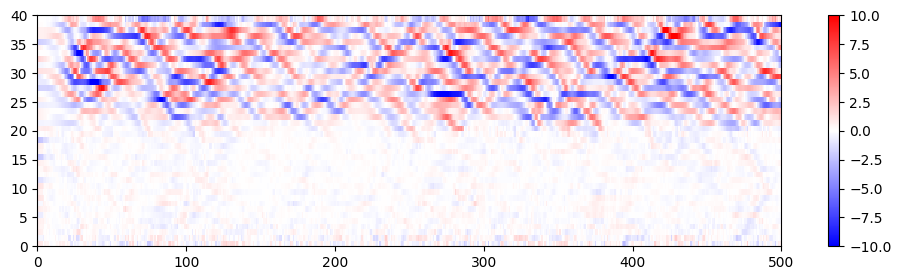

In [16]:
# Hovmoeller diagram of the posterior error against the truth
plt.figure(figsize=(12,3))
c = plt.pcolor((np.mean(post_state, axis=1) - truth_state).T, vmin=-10, vmax=10, cmap='bwr')
plt.colorbar(c)

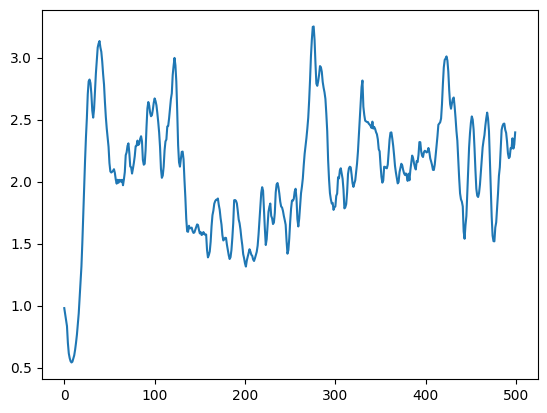

In [15]:
# time series of domain-averaged rmse 
# of posterior state against the truth
plt.plot(np.sqrt(mse_ts))

## Experiment with different parameters

Reproducing Fig. 5.7 of [Bocquet's lecture notes](https://cerea.enpc.fr/HomePages/bocquet/teaching/assim-mb-en-0.52.pdf), section 5.5. The original figure compares the deterministic EnKF (ETKF) under four combinations of localization and inflation, as ensemble size varies from 5 to 50:

1. **no localization, no inflation** -- the EnKF is "doomed" without either
2. **no localization, optimally-tuned inflation**
3. **optimally-tuned localization, no inflation**
4. **optimally-tuned localization and inflation** -- best of the four

In this section, observation operator H=I (every grid point observed), R=I (observation error std=1). We test a handful of ensemble sizes `nens`, localization radii `hroi`, and inflation coefficients `infl`.

**On seed averaging:** curves 1 and 3 ("no inflation") are numerically marginal -- without inflation, the EnKF is only weakly stable, so individual runs can survive or diverge somewhat unpredictably near the critical ensemble size. A single run's RMSE there isn't very meaningful; we average over several random seeds instead. Marc Bocquet himself confirmed this by email: *"There is no point in looking at the actual values of the RMSEs in the absence of inflation... I usually either use a long run, or an ensemble of shorter runs to make the quantitative results more reliable."*

To keep this demo quick (a few minutes on a laptop), we use a much-reduced grid, shorter cycles (nt=200 vs. the 500 used above), and fewer seeds than the full HPC-scale reproduction (17 ensemble sizes x 12 localization radii x 7 inflation values x 100 seeds) used in the NEDAS introduction paper -- enough to see the qualitative shape of all four curves, not a precise quantitative match.

The sweep below uses [`concurrent.futures.ProcessPoolExecutor`](https://docs.python.org/3/library/concurrent.futures.html) (with an explicit `fork` start method) to parallelize across CPU cores, capped at 10. **Note:** running process-based parallelism directly inside a live Jupyter kernel can be fragile on some platforms (observed crashing with `BrokenProcessPool` on macOS in testing, seemingly from interaction with the kernel's own background threads, while the identical code works fine as a plain script) -- if this cell fails for you, try restarting the kernel, or fall back to `joblib.Parallel(n_jobs=nproc, backend='loky')` instead, which is built to handle exactly this situation robustly.

In [9]:
import os
import time
import multiprocessing as mp
from datetime import timedelta
from concurrent.futures import ProcessPoolExecutor, as_completed

# a much-reduced grid vs. the full HPC-scale reproduction (17 nens x 12 hroi x
# 7 infl x 100 seeds) -- enough to see the qualitative shape of all 4 curves
# in a few minutes on a laptop
nens_try = [5, 7, 10, 14, 18, 22, 28, 35, 50]
hroi_try = [2, 5, 10, 25, 60]
infl_try = [1.0, 1.05, 1.1, 1.2]
seeds = list(range(3000, 3010))  # 10 seeds
ncycle_demo = 100
burnin_demo = 50

def run_case(args):
    curve, nens, hroi, infl, seed = args
    config = Config(config_file="lorenz96/config.yml", quiet=True,
                     work_dir=f"lorenz96/work_demo_{os.getpid()}")
    config.time_end = config.time_start + ncycle_demo * timedelta(hours=config.cycle_period)
    config.time_analysis_end = config.time_end
    config.assimilator_def['type'] = 'ETKF'
    config.nens = nens
    config.obs_def[obs_rec_id]['hroi'] = hroi
    config.inflation_def['coef'] = infl
    config.seed = seed
    scheme = get_scheme(config)
    scheme()
    truth_state = get_truth(scheme)
    post_state = get_model_state(scheme, 'post')
    mse_ts = np.mean((np.mean(post_state, axis=1) - truth_state) ** 2, axis=1)
    return curve, nens, hroi, infl, seed, np.sqrt(np.mean(mse_ts[burnin_demo:]))

tasks = []
for nens in nens_try:
    for seed in seeds:
        tasks.append((1, nens, np.inf, 1.01, seed))
    for infl in infl_try:
        for seed in seeds:
            tasks.append((2, nens, np.inf, infl, seed))
    for hroi in hroi_try:
        for seed in seeds:
            tasks.append((3, nens, hroi, 1.01, seed))
    for hroi in hroi_try:
        for infl in infl_try:
            for seed in seeds:
                tasks.append((4, nens, hroi, infl, seed))
print(f'{len(tasks)} total cases (ncycle={ncycle_demo}, burnin={burnin_demo}, {len(seeds)} seeds)')

2700 total cases (ncycle=100, burnin=50, 10 seeds)


In [ ]:
%rm -rf lorenz96/work_demo_*

nproc = os.cpu_count()
print(f'using {nproc} processes')
ctx = mp.get_context('fork')

curve1_data, curve2_data, curve3_data, curve4_data = {}, {}, {}, {}
ntotal = len(tasks)
ndone = 0
t0 = time.time()
with ProcessPoolExecutor(max_workers=nproc, mp_context=ctx) as ex:
    futures = [ex.submit(run_case, t) for t in tasks]
    for future in as_completed(futures):
        curve, nens, hroi, infl, seed, rmse_val = future.result()
        if curve == 1:
            curve1_data.setdefault(nens, []).append(rmse_val)
        elif curve == 2:
            curve2_data.setdefault((nens, infl), []).append(rmse_val)
        elif curve == 3:
            curve3_data.setdefault((nens, hroi), []).append(rmse_val)
        elif curve == 4:
            curve4_data.setdefault((nens, hroi, infl), []).append(rmse_val)
        ndone += 1
        # progress printout every 50 cases (and always the last one) so the
        # notebook doesn't look hung during the several-minute sweep
        if ndone % 50 == 0 or ndone == ntotal:
            elapsed = time.time() - t0
            rate = ndone / elapsed
            eta = (ntotal - ndone) / rate if rate > 0 else 0
            print(f'{ndone}/{ntotal} cases done ({100*ndone/ntotal:.0f}%), '
                  f'elapsed {elapsed:.0f}s, ETA {eta:.0f}s', flush=True)

# curve = mean over seeds; for curves 2-4, take the (infl, hroi, or hroi+infl)
# combo that minimizes the mean, and report std over seeds *at that same combo*
# (not the std of the already-minimized means) so the shaded band reflects
# actual run-to-run scatter, not spread across parameter choices
curve1 = np.array([np.mean(curve1_data[n]) for n in nens_try])
std1 = np.array([np.std(curve1_data[n]) for n in nens_try])

curve2, std2 = [], []
for n in nens_try:
    means = {i: np.mean(curve2_data[(n, i)]) for i in infl_try}
    best_i = min(means, key=means.get)
    curve2.append(means[best_i])
    std2.append(np.std(curve2_data[(n, best_i)]))
curve2, std2 = np.array(curve2), np.array(std2)

curve3, std3 = [], []
for n in nens_try:
    means = {h: np.mean(curve3_data[(n, h)]) for h in hroi_try}
    best_h = min(means, key=means.get)
    curve3.append(means[best_h])
    std3.append(np.std(curve3_data[(n, best_h)]))
curve3, std3 = np.array(curve3), np.array(std3)

curve4, std4 = [], []
for n in nens_try:
    means = {(h, i): np.mean(curve4_data[(n, h, i)]) for h in hroi_try for i in infl_try}
    best_hi = min(means, key=means.get)
    curve4.append(means[best_hi])
    std4.append(np.std(curve4_data[(n, *best_hi)]))
curve4, std4 = np.array(curve4), np.array(std4)

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(6,5))

def plot_curve(curve, std, color, marker, label):
    lo = np.maximum(curve - std, 0.05)
    hi = curve + std
    ax.fill_between(nens_try, lo, hi, color=color, alpha=0.15, linewidth=0)
    ax.loglog(nens_try, curve, color + marker + '-', markerfacecolor='none', markersize=8, label=label)

plot_curve(curve1, std1, 'k', 's', 'no loc. no infl.')
plot_curve(curve2, std2, 'b', 'o', 'no loc. opt. infl.')
plot_curve(curve3, std3, 'g', 'D', 'opt. loc. no infl.')
plot_curve(curve4, std4, 'r', '^', 'opt. loc. opt. infl.')

ax.set_xlim([4, 55])
ax.set_xticks(nens_try)
ax.set_xticklabels(nens_try)
ax.set_ylim([0.05, 8])
ylevs = [0.1, 0.2, 0.3, 0.5, 1, 2, 3, 5]
ax.set_yticks(ylevs)
ax.set_yticklabels(ylevs)
ax.grid()
ax.legend(loc='upper right')
ax.set_xlabel('Ensemble size')
ax.set_ylabel('Average analysis RMSE')
ax.set_title(f'Bocquet (2015) Fig. 5.7 reproduction, NEDAS ETKF\n'
             f'({len(seeds)} seeds, nt={ncycle_demo}, {nproc} processes, shaded: +/-1 std)')
plt.tight_layout()
plt.savefig('lorenz96/bocquet_fig57_demo.png', dpi=120)